# BDA IA2: Distributed Fake News Detection Pipeline using PySpark

**Dataset used:** Clement Bisaillon's Fake and Real News Dataset (Kaggle)

*Please run the cells below to initialize the Apache Spark context and begin distributed big data ingestion via HDFS/local clustering.*

In [1]:
# Cell 1 - Setup
import os
import sys
import time
import re

try:
    import psutil as _psutil
    _PSUTIL_OK = True
except ImportError:
    _PSUTIL_OK = False

def _ram_mb():
    """Current process RSS in MB, or 0 if psutil unavailable."""
    if _PSUTIL_OK:
        return _psutil.Process(os.getpid()).memory_info().rss / 1024 / 1024
    return 0.0

# ─── Path constants ──────────────────────────────────────────────
# Assume the notebook is running inside Group_XX_Implementation/
DATASET_DIR  = "Dataset"
FAKE_CSV     = os.path.join(DATASET_DIR, "Fake.csv")
TRUE_CSV     = os.path.join(DATASET_DIR, "True.csv")
OUTPUT_DIR   = "Output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

USE_SPARK = False   # Will be flipped to True if Spark init succeeds


In [2]:
# Cell 2 - Spark Init
def init_spark():
    global USE_SPARK
    import os

    os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-17"
    os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

    try:
        import findspark
        findspark.init()

        from pyspark.sql import SparkSession

        spark = (
            SparkSession.builder
            .appName("FakeNewsDetection")
            .master("local[*]")
            .config("spark.driver.host", "127.0.0.1")
            .config("spark.driver.bindAddress", "127.0.0.1")
            .config("spark.ui.enabled", "false")

            # MAX MEMORY USAGE (your 16GB RAM)
            .config("spark.driver.memory", "12g")
            .config("spark.executor.memory", "12g")
            .config("spark.memory.fraction", "0.8")
            .config("spark.memory.storageFraction", "0.3")

            # CONTROL PARALLELISM (avoid overload)
            .config("spark.sql.shuffle.partitions", "4")
            .config("spark.default.parallelism", "4")
            .config("spark.executor.cores", "2")

            # PREVENT RESULT SIZE CRASH
            .config("spark.driver.maxResultSize", "2g")

            # JAVA 17 FIX
            .config(
                "spark.driver.extraJavaOptions",
                "-XX:+IgnoreUnrecognizedVMOptions "
                "--add-opens=java.base/java.lang=ALL-UNNAMED "
                "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED "
                "--add-opens=java.base/java.io=ALL-UNNAMED "
                "--add-opens=java.base/java.net=ALL-UNNAMED "
                "--add-opens=java.base/java.nio=ALL-UNNAMED "
                "--add-opens=java.base/java.util=ALL-UNNAMED "
                "--add-opens=java.base/java.util.concurrent=ALL-UNNAMED "
                "--add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED"
            )

            .getOrCreate()
        )

        spark.sparkContext.setLogLevel("ERROR")
        USE_SPARK = True
        print(f"[OK] Spark initialized: {spark.version}")
        return spark

    except Exception as e:
        print(f"[WARN] Spark init failed: {e}")
        print("[INFO] Falling back to pandas mode")
        return None


spark = init_spark()

[OK] Spark initialized: 4.1.1


In [3]:
# Cell 3 - Load Data
def load_data_spark(spark):
    from pyspark.sql.functions import lit
    fake_df = spark.read.csv(FAKE_CSV, header=True, inferSchema=True).withColumn("label", lit(1))
    true_df = spark.read.csv(TRUE_CSV, header=True, inferSchema=True).withColumn("label", lit(0))
    return fake_df.union(true_df)

def load_data_pandas():
    import pandas as pd
    fake_df = pd.read_csv(FAKE_CSV)
    true_df = pd.read_csv(TRUE_CSV)
    fake_df["label"] = 1
    true_df["label"] = 0
    return pd.concat([fake_df, true_df], ignore_index=True)

def load_data(spark=None):
    for path in (FAKE_CSV, TRUE_CSV):
        if not os.path.exists(path):
            print(f"[ERROR] Dataset not found: {path} - Please ensure it is in the Dataset/ directory")
            return None

    if USE_SPARK and spark is not None:
        df = load_data_spark(spark)
        print("[OK]  Datasets loaded with PySpark")
    else:
        df = load_data_pandas()
        print("[OK]  Datasets loaded with pandas")

    return df

df = load_data(spark)


[OK]  Datasets loaded with PySpark


In [4]:
# Cell 4 - Dataset Info
def show_info(df):
    if df is None: return
    if USE_SPARK:
        print("\n── Schema ──────────────────────────────────────")
        df.printSchema()
        print("\n── First 5 rows ────────────────────────────────")
        df.show(5, truncate=80)
        print(f"\n── Total rows: {df.count():,} ─────────────────────────")
    else:
        print("\n── Columns / dtypes ────────────────────────────")
        print(df.dtypes)
        print("\n── First 5 rows ────────────────────────────────")
        print(df.head(5).to_string(index=False))
        print(f"\n── Total rows: {len(df):,} ─────────────────────────")

def show_dataset_stats(df, feat_dim=None):
    if df is None: return
    print("\n── Dataset Composition (Section 8.1) ────────────────")
    if USE_SPARK:
        total     = df.count()
        fake_cnt  = df.filter(df.label == 1).count()
        true_cnt  = df.filter(df.label == 0).count()
    else:
        total     = len(df)
        fake_cnt  = int((df["label"] == 1).sum())
        true_cnt  = int((df["label"] == 0).sum())
    print(f"  Total Labeled Records : {total:,}")
    print(f"  Fake News (label=1)   : {fake_cnt:,}")
    print(f"  True News (label=0)   : {true_cnt:,}")
    print(f"  Train / Test Split    : 80% / 20%")
    if feat_dim is not None:
        print(f"  TF-IDF Feature Dim    : {feat_dim:,}")
    return total, fake_cnt, true_cnt

show_info(df)
show_dataset_stats(df)



── Schema ──────────────────────────────────────
root
 |-- title: string (nullable = true)
 |-- text: string (nullable = true)
 |-- subject: string (nullable = true)
 |-- date: string (nullable = true)
 |-- label: integer (nullable = false)


── First 5 rows ────────────────────────────────
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+-------+-----------------+-----+
|                                                                           title|                                                                            text|subject|             date|label|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+-------+-----------------+-----+
|  Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing|Donald Trump just couldn t wish all A

(44906, 23489, 21417)

In [5]:
# Cell 5 - Preprocessing
_STOPWORDS = {
    "a","about","above","after","again","against","all","am","an","and",
    "any","are","aren't","as","at","be","because","been","before","being",
    "below","between","both","but","by","can't","cannot","could","couldn't",
    "did","didn't","do","does","doesn't","doing","don't","down","during",
    "each","few","for","from","further","get","got","had","hadn't","has",
    "hasn't","have","haven't","having","he","he'd","he'll","he's","her",
    "here","here's","hers","herself","him","himself","his","how","how's",
    "i","i'd","i'll","i'm","i've","if","in","into","is","isn't","it",
    "it's","its","itself","let's","me","more","most","mustn't","my",
    "myself","no","nor","not","of","off","on","once","only","or","other",
    "ought","our","ours","ourselves","out","over","own","same","shan't",
    "she","she'd","she'll","she's","should","shouldn't","so","some","such",
    "than","that","that's","the","their","theirs","them","themselves","then",
    "there","there's","these","they","they'd","they'll","they're","they've",
    "this","those","through","to","too","under","until","up","very","was",
    "wasn't","we","we'd","we'll","we're","we've","were","weren't","what",
    "what's","when","when's","where","where's","which","while","who",
    "who's","whom","why","why's","will","with","won't","would","wouldn't",
    "you","you'd","you'll","you're","you've","your","yours","yourself",
    "yourselves","said","also","s","re","ve","ll","t","d",
}

def preprocess_spark(spark, df):
    from pyspark.ml.feature import RegexTokenizer, StopWordsRemover
    from pyspark.sql.functions import col

    text_col = "text" if "text" in df.columns else df.columns[0]
    df = df.filter(col(text_col).isNotNull())

    tokenizer = RegexTokenizer(
        inputCol=text_col, outputCol="tokens", pattern=r"[^a-zA-Z]+", toLowercase=True, minTokenLength=2
    )
    df = tokenizer.transform(df)

    remover = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")
    df = remover.transform(df)
    return df, text_col

def preprocess_pandas(df):
    import re
    text_col = "text" if "text" in df.columns else df.columns[0]
    df = df.dropna(subset=[text_col]).copy()
    df["tokens"] = df[text_col].str.lower().apply(lambda s: [t for t in re.split(r"[^a-zA-Z]+", s) if len(t) >= 2])
    df["filtered_tokens"] = df["tokens"].apply(lambda toks: [t for t in toks if t not in _STOPWORDS])
    return df, text_col

def preprocess(spark, df):
    if df is None: return None, None
    if USE_SPARK and spark is not None:
        df, text_col = preprocess_spark(spark, df)
        print("[OK]  Preprocessing done (PySpark)")
    else:
        df, text_col = preprocess_pandas(df)
        print("[OK]  Preprocessing done (pandas)")
    return df, text_col

def show_preprocessed(df, text_col):
    if df is None: return
    cols = [text_col, "tokens", "filtered_tokens"]
    print("\n── Preprocessed sample (5 rows) ────────────────")
    if USE_SPARK:
        df.select(*cols).show(5, truncate=100)
    else:
        display_df = df[cols].head(5).copy()
        display_df[text_col] = display_df[text_col].str[:80]
        display_df["tokens"]          = display_df["tokens"].apply(lambda x: x[:8])
        display_df["filtered_tokens"] = display_df["filtered_tokens"].apply(lambda x: x[:8])
        print(display_df.to_string(index=False))

df, text_col = preprocess(spark, df)
show_preprocessed(df, text_col)


[OK]  Preprocessing done (PySpark)

── Preprocessed sample (5 rows) ────────────────
+----------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+
|                                                                                                text|                                                                                              tokens|                                                                                     filtered_tokens|
+----------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+


In [6]:
# Cell 6 - Feature Engineering
def feature_engineering_spark(df):
    from pyspark.ml.feature import HashingTF, IDF, CountVectorizer

    t0       = time.time()
    cv       = CountVectorizer(inputCol="filtered_tokens", outputCol="tf_raw", vocabSize=50_000, minDF=2.0)
    cv_model = cv.fit(df)
    df_tf    = cv_model.transform(df)
    idf       = IDF(inputCol="tf_raw", outputCol="tfidf_features")
    idf_model = idf.fit(df_tf)
    df_tfidf  = idf_model.transform(df_tf)
    tfidf_time = time.time() - t0

    t0          = time.time()
    htf         = HashingTF(inputCol="filtered_tokens", outputCol="hash_raw", numFeatures=50_000)
    df_htf      = htf.transform(df)
    idf_h       = IDF(inputCol="hash_raw", outputCol="hash_features")
    idf_h_model = idf_h.fit(df_htf)
    df_hash     = idf_h_model.transform(df_htf)
    hash_time   = time.time() - t0

    print(f"[OK]  TF-IDF build: {tfidf_time:.2f}s | HashingTF+IDF build: {hash_time:.2f}s (PySpark)")
    return {"tfidf": (df_tfidf, "tfidf_features", tfidf_time),
            "hash":  (df_hash,  "hash_features",  hash_time)}

def feature_engineering_pandas(df):
    from sklearn.feature_extraction.text import TfidfVectorizer, HashingVectorizer

    corpus = df["filtered_tokens"].apply(lambda toks: " ".join(toks))
    y      = df["label"].values

    t0        = time.time()
    tfidf_vec = TfidfVectorizer(max_features=50_000, sublinear_tf=True)
    X_tfidf   = tfidf_vec.fit_transform(corpus)
    tfidf_time = time.time() - t0
    feat_dim  = X_tfidf.shape[1]

    t0       = time.time()
    hash_vec = HashingVectorizer(n_features=50_000, alternate_sign=False)
    X_hash   = hash_vec.fit_transform(corpus)
    hash_time = time.time() - t0

    print(f"[OK]  TF-IDF build: {tfidf_time:.2f}s (dim={feat_dim:,}) | HashingTF build: {hash_time:.2f}s (pandas)")
    return ({"tfidf": (X_tfidf, y, tfidf_time), "hash":  (X_hash,  y, hash_time)}, feat_dim)

def feature_engineering(spark, df):
    if df is None: return {}, "none", None
    if USE_SPARK and spark is not None:
        return feature_engineering_spark(df), "spark", None
    else:
        feats_dict, feat_dim = feature_engineering_pandas(df)
        return feats_dict, "pandas", feat_dim

features_dict, mode, feat_dim = feature_engineering(spark, df)
if df is not None:
    show_dataset_stats(df, feat_dim=feat_dim)

df_pandas_pre = None
if df is not None:
    if mode == "spark":
        try:
            df_pandas_pre = df.select("filtered_tokens", "label").toPandas()
            df_pandas_pre["filtered_tokens"] = df_pandas_pre["filtered_tokens"].apply(
                lambda x: list(x) if not isinstance(x, list) else x
            )
        except Exception as _e:
            print(f"[WARN] Could not fetch pandas mirror: {_e}")
    else:
        df_pandas_pre = df


[OK]  TF-IDF build: 9.99s | HashingTF+IDF build: 3.27s (PySpark)

── Dataset Composition (Section 8.1) ────────────────
  Total Labeled Records : 44,898
  Fake News (label=1)   : 23,481
  True News (label=0)   : 21,417
  Train / Test Split    : 80% / 20%


In [7]:
# Cell 7 - Model Training
def _fmt(v):
    return f"{v:.4f}"

def train_and_evaluate_spark(features_dict):
    from pyspark.ml.classification import LogisticRegression as SparkLR, DecisionTreeClassifier as SparkDT, RandomForestClassifier as SparkRF
    from pyspark.ml.evaluation import MulticlassClassificationEvaluator

    results = []
    spark_total_t0 = time.time()

    for feat_name, (df_feat, feat_col, build_time) in features_dict.items():
        train_df, test_df = df_feat.randomSplit([0.8, 0.2], seed=42)
        train_df.cache(); test_df.cache()

        model_defs = [
            ("LR", SparkLR(featuresCol=feat_col, labelCol="label", maxIter=20)),
            ("DT", SparkDT(featuresCol=feat_col, labelCol="label", maxDepth=10)),
            ("RF", SparkRF(featuresCol=feat_col, labelCol="label", numTrees=100, maxDepth=10)),
        ]

        for model_name, model in model_defs:
            ram_before = _ram_mb()
            t0         = time.time()
            fitted     = model.fit(train_df)
            train_time = time.time() - t0
            ram_after  = _ram_mb()
            peak_ram   = ram_after - ram_before
            preds      = fitted.transform(test_df)

            def _eval(metric, _preds=preds):
                return MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName=metric).evaluate(_preds)

            results.append({
                "Model": model_name, "Feature": feat_name.upper(), "BuildTime": build_time,
                "Accuracy": _eval("accuracy"), "Precision": _eval("weightedPrecision"), "Recall": _eval("weightedRecall"), "F1": _eval("f1"),
                "TrainTime": train_time, "PeakRAM": peak_ram,
            })
            print(f"  [done] {model_name} + {feat_name.upper()} (train={train_time:.1f}s, RAM delta={peak_ram:.1f} MB)")
        train_df.unpersist(); test_df.unpersist()

    spark_total = time.time() - spark_total_t0
    print(f"\n[Comparison 1] Spark total training time: {spark_total:.2f}s")
    return results

def train_and_evaluate_pandas(features_dict):
    from sklearn.linear_model import LogisticRegression as SkLR
    from sklearn.tree import DecisionTreeClassifier as SkDT
    from sklearn.ensemble import RandomForestClassifier as SkRF
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    model_defs = [
        ("LR", SkLR(max_iter=1000, solver="saga", n_jobs=-1)),
        ("DT", SkDT(max_depth=10, random_state=42)),
        ("RF", SkRF(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
    ]

    results = []
    sklearn_total_t0 = time.time()

    for feat_name, (X, y, build_time) in features_dict.items():
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        for model_name, model in model_defs:
            ram_before = _ram_mb()
            t0         = time.time()
            model.fit(X_train, y_train)
            train_time = time.time() - t0
            ram_after  = _ram_mb()
            peak_ram   = ram_after - ram_before
            y_pred     = model.predict(X_test)

            results.append({
                "Model": model_name, "Feature": feat_name.upper(), "BuildTime": build_time,
                "Accuracy": accuracy_score(y_test, y_pred), "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0), "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0), "F1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
                "TrainTime": train_time, "PeakRAM": peak_ram,
            })
            print(f"  [done] {model_name} + {feat_name.upper()} (train={train_time:.1f}s, RAM delta={peak_ram:.1f} MB)")

    sklearn_total = time.time() - sklearn_total_t0
    print(f"\n[Comparison 1] Sklearn total training time: {sklearn_total:.2f}s")
    return results, sklearn_total

def train_and_evaluate(spark, features_dict, mode, df_pandas_preprocessed=None):
    if not features_dict: return []
    print("\n── Training models ─────────────────────────────────────────────────")
    sklearn_time = None
    if mode == "spark":
        results = train_and_evaluate_spark(features_dict)
        if df_pandas_preprocessed is not None:
            print("\n── [Comparison 1] Running sklearn mirror for timing ─────────────")
            try:
                from sklearn.feature_extraction.text import TfidfVectorizer
                from sklearn.ensemble import RandomForestClassifier
                from sklearn.model_selection import train_test_split
                corpus = df_pandas_preprocessed["filtered_tokens"].apply(lambda t: " ".join(t))
                X_sk   = TfidfVectorizer(max_features=50_000, sublinear_tf=True).fit_transform(corpus)
                y_sk   = df_pandas_preprocessed["label"].values
                X_tr, X_te, y_tr, _ = train_test_split(X_sk, y_sk, test_size=0.2, random_state=42, stratify=y_sk)
                t0 = time.time()
                RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1).fit(X_tr, y_tr)
                sklearn_time = time.time() - t0
            except Exception as e:
                print(f"[WARN] sklearn mirror failed: {e}")
        spark_total = sum(r["TrainTime"] for r in results)
        sk_str = f"{sklearn_time:.2f}s" if sklearn_time is not None else "N/A"
        print(f"\n[Comparison 1] Sklearn: {sk_str} | Spark: {spark_total:.2f}s")
    else:
        results, sklearn_time = train_and_evaluate_pandas(features_dict)
        print(f"\n[Comparison 1] Sklearn: {sklearn_time:.2f}s | Spark: N/A (not available)")
    return results

def print_results_table(results):
    if not results: return
    header = (f"{'Model':<6} {'Feature':<8} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'TrainTime(s)':>14}")
    sep    = "─" * len(header)
    print(f"\n{sep}\n{header}\n{sep}")
    for r in results:
        print(f"{r['Model']:<6} {r['Feature']:<8} {_fmt(r['Accuracy']):>10} {_fmt(r['Precision']):>10} {_fmt(r['Recall']):>10} {_fmt(r['F1']):>10} {r['TrainTime']:>13.2f}s")
    print(sep)
    best = max(results, key=lambda x: x["F1"])
    print(f"\n★  Best model by F1 : {best['Model']} + {best['Feature']}  →  F1={_fmt(best['F1'])}  Acc={_fmt(best['Accuracy'])}  TrainTime={best['TrainTime']:.2f}s")

def run_scalability_test_pandas(df_preprocessed):
    import pandas as pd
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split
    if df_preprocessed is None: return
    print("\n── Scalability Test: 2x Data (RF + TF-IDF) ─────────────────────")
    df_2x   = pd.concat([df_preprocessed, df_preprocessed], ignore_index=True)
    corpus  = df_2x["filtered_tokens"].apply(lambda toks: " ".join(toks))
    y_2x    = df_2x["label"].values
    X_2x    = TfidfVectorizer(max_features=50_000, sublinear_tf=True).fit_transform(corpus)
    X_tr, _, y_tr, _ = train_test_split(X_2x, y_2x, test_size=0.2, random_state=42, stratify=y_2x)
    clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    t0 = time.time()
    clf.fit(X_tr, y_tr)
    t2x = time.time() - t0
    print(f"  2x Data Training Time: {t2x:.2f}s  (rows={len(df_2x):,})")

results = train_and_evaluate(spark, features_dict, mode, df_pandas_preprocessed=df_pandas_pre)
print_results_table(results)
run_scalability_test_pandas(df_pandas_pre)


── Training models ─────────────────────────────────────────────────
  [done] LR + TFIDF (train=9.4s, RAM delta=0.0 MB)
  [done] DT + TFIDF (train=38.5s, RAM delta=-740.8 MB)
  [done] RF + TFIDF (train=49.6s, RAM delta=9.0 MB)
  [done] LR + HASH (train=8.2s, RAM delta=1.3 MB)
  [done] DT + HASH (train=33.8s, RAM delta=-22.8 MB)
  [done] RF + HASH (train=61.1s, RAM delta=16.2 MB)

[Comparison 1] Spark total training time: 214.60s

── [Comparison 1] Running sklearn mirror for timing ─────────────

[Comparison 1] Sklearn: 0.77s | Spark: 200.59s

──────────────────────────────────────────────────────────────────────────
Model  Feature    Accuracy  Precision     Recall         F1   TrainTime(s)
──────────────────────────────────────────────────────────────────────────
LR     TFIDF        0.9808     0.9808     0.9808     0.9808          9.40s
DT     TFIDF        0.9951     0.9951     0.9951     0.9951         38.52s
RF     TFIDF        0.9727     0.9727     0.9727     0.9727         49.60s



── Generating visualisations (Section 8.5) ─────────────────


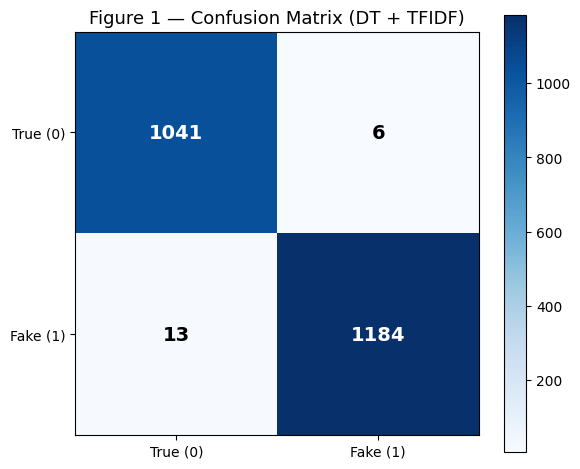

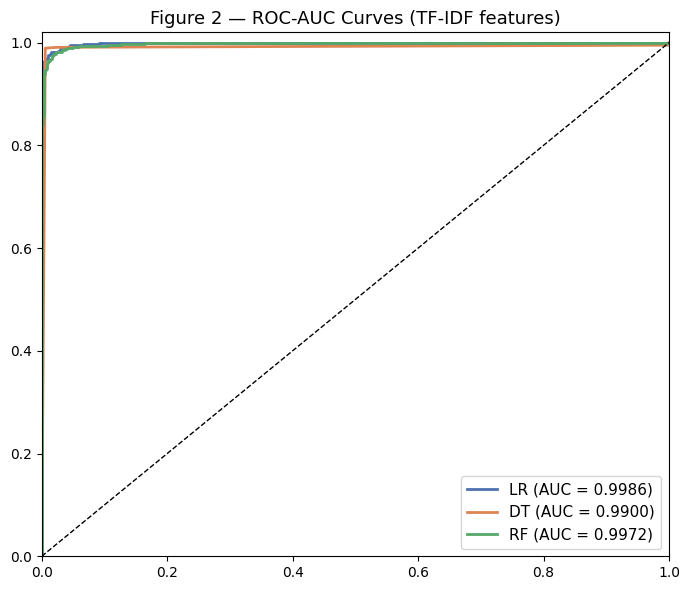

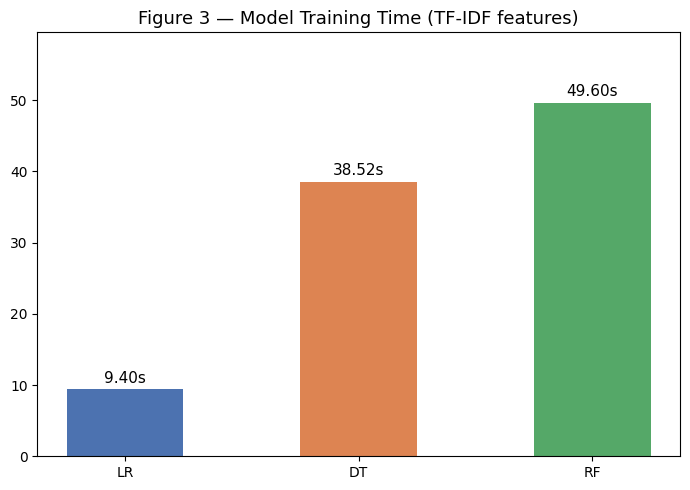

In [10]:
# Cell 8 - Visualization
def generate_visualizations(results, features_dict, mode):
    if not results: return
    try:
        from IPython.display import Image, display
        import matplotlib.pyplot as plt
        import numpy as np
    except ImportError:
        print("[WARN] matplotlib not installed")
        return

    def _get_sklearn_Xy(feat_key="tfidf"):
        from sklearn.model_selection import train_test_split
        if mode == "pandas":
            X, y, _ = features_dict[feat_key]
        else:
            from sklearn.feature_extraction.text import TfidfVectorizer
            spark_df, feat_col, _ = features_dict[feat_key]
            # FIX: Replaced .limit(10000) with .sample() to ensure both True (0) and Fake (1) are included!
            pdf = spark_df.select("filtered_tokens", "label").sample(False, 0.25, seed=42).toPandas()
            corpus = pdf["filtered_tokens"].apply(lambda t: " ".join(t))
            y      = pdf["label"].values
            X      = TfidfVectorizer(max_features=50_000, sublinear_tf=True).fit_transform(corpus)
        return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 1. Confusion Matrix
    try:
        from sklearn.metrics import confusion_matrix
        best     = max(results, key=lambda x: x["F1"])
        feat_key = best["Feature"].lower()
        X_train, X_test, y_train, y_test = _get_sklearn_Xy(feat_key)

        from sklearn.ensemble import RandomForestClassifier
        from sklearn.linear_model import LogisticRegression
        from sklearn.tree import DecisionTreeClassifier

        if best["Model"] == "LR": clf = LogisticRegression(max_iter=1000, solver="saga", n_jobs=None)
        elif best["Model"] == "DT": clf = DecisionTreeClassifier(max_depth=10, random_state=42)
        else: clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=None)
        
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
        plt.colorbar(im, ax=ax)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(["True (0)", "Fake (1)"])
        ax.set_yticklabels(["True (0)", "Fake (1)"])
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14, fontweight="bold")
        ax.set_title(f"Figure 1 — Confusion Matrix ({best['Model']} + {best['Feature']})", fontsize=13)
        plt.tight_layout()
        out1 = os.path.join(OUTPUT_DIR, "figure1_confusion_matrix.png")
        fig.savefig(out1, dpi=150)
        plt.show()
    except Exception as e:
        print(f"[WARN] Figure 1 skipped: {e}")

    # 2. ROC-AUC
    try:
        from sklearn.metrics import roc_curve, auc
        X_train, X_test, y_train, y_test = _get_sklearn_Xy("tfidf")
        roc_model_defs = [
            ("LR", LogisticRegression(max_iter=1000, solver="saga", n_jobs=None)), 
            ("DT", DecisionTreeClassifier(max_depth=10, random_state=42)), 
            ("RF", RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=None)),
        ]
        colors = ["#4C72B0", "#DD8452", "#55A868"]
        fig, ax = plt.subplots(figsize=(7, 6))
        for (mname, clf), color in zip(roc_model_defs, colors):
            clf.fit(X_train, y_train)
            scores = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else clf.decision_function(X_test)
            fpr, tpr, _ = roc_curve(y_test, scores)
            ax.plot(fpr, tpr, color=color, lw=2, label=f"{mname} (AUC = {auc(fpr, tpr):.4f})")
        ax.plot([0, 1], [0, 1], "k--", lw=1)
        ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.02])
        ax.set_title("Figure 2 — ROC-AUC Curves (TF-IDF features)", fontsize=13)
        ax.legend(loc="lower right", fontsize=11)
        plt.tight_layout()
        out2 = os.path.join(OUTPUT_DIR, "figure2_roc_auc.png")
        fig.savefig(out2, dpi=150)
        plt.show()
    except Exception as e:
        print(f"[WARN] Figure 2 skipped: {e}")

    # 3. Bar Chart
    try:
        tfidf_results = [r for r in results if r["Feature"] == "TFIDF"] or results
        model_names = [r["Model"] for r in tfidf_results]
        train_times = [r["TrainTime"] for r in tfidf_results]
        fig, ax = plt.subplots(figsize=(7, 5))
        bars = ax.bar(model_names, train_times, color=["#4C72B0", "#DD8452", "#55A868"], width=0.5)
        for bar, val in zip(bars, train_times):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(train_times)*0.01, f"{val:.2f}s", ha="center", va="bottom", fontsize=11)
        ax.set_title("Figure 3 — Model Training Time (TF-IDF features)", fontsize=13)
        ax.set_ylim(0, max(train_times) * 1.2 if train_times else 1)
        plt.tight_layout()
        out3 = os.path.join(OUTPUT_DIR, "figure3_training_time.png")
        fig.savefig(out3, dpi=150)
        plt.show()
    except Exception as e:
        print(f"[WARN] Figure 3 skipped: {e}")

print("\n── Generating visualisations (Section 8.5) ─────────────────")
if 'results' not in globals() or not results:
    print("[ERROR] Variable 'results' is missing. Please ensure Cell 7 (Model Training) completes fully without errors before running Cell 8.")
else:
    generate_visualizations(results, features_dict, mode)
